# 📚 Amazon Bestsellers: Price vs User Rating Correlation Analysis

## 📌 Table of Contents
1. [Introduction & Business Objective](#1)
2. [Data Loading & Library Imports](#2)
3. [Data Inspection & Health Check](#3)
4. [Data Cleaning (Removing Duplicates)](#4)
5. [Exploratory Data Analysis (EDA)](#5)
    - 5.1 [Price Distribution](#5.1)
    - 5.2 [User Rating Distribution](#5.2)
    - 5.3 [Correlation Analysis (Price vs. Rating)](#5.3)
    - 5.4 [Fiction vs. Non-Fiction Strategy](#5.4)
6. [Key Insights & Strategic Recommendations](#6)
7. [Connection to Tableau Dashboard](#7)

# <a id="1"></a> 1. Introduction & Business Objective
Does a higher price tag guarantee a better user experience? In this notebook, we analyze the **Amazon Top 50 Bestselling Books (2009-2019)** to identify the relationship between pricing strategy and customer satisfaction.

**The Objective:** To help publishers and retailers understand if premium pricing affects book ratings and how genres differ in their market performance.

# <a id="2"></a> 2. Data Loading & Library Imports
We use **Seaborn** and **Matplotlib** for initial statistical plots and **Pandas** for data manipulation.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Path check kar lena (Copy path from input section)
path = '/kaggle/input/datasets/obaidhere/amazon-bestsellers-price-vs-user-rating-analysis/bestsellers with categories.csv'
df = pd.read_csv(path)
print("Amazon Bestsellers Data Loaded Successfully!")

Amazon Bestsellers Data Loaded Successfully!


# <a id="3"></a> 3. Data Inspection & Health Check
We check for the number of books, categories, and the overall range of prices and ratings.

In [2]:
print("Dataset Dimensions:", df.shape)
display(df.head())
display(df.describe())

Dataset Dimensions: (550, 7)


,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


,User Rating,Reviews,Price,Year
count,550.000000,550.000000,550.000000,550.000000
mean,4.618364,11953.281818,13.100000,2014.000000
std,0.226980,11731.132017,10.842262,3.165156
min,3.300000,37.000000,0.000000,2009.000000
25%,4.500000,4058.000000,7.000000,2011.000000
50%,4.700000,8580.000000,11.000000,2014.000000
75%,4.800000,17253.250000,16.000000,2017.000000
max,4.900000,87841.000000,105.000000,2019.000000


# <a id="4"></a> 4. Data Cleaning
Bestseller lists often have the same book appearing in multiple years. We will check for duplicates to ensure our correlation isn't skewed.

In [3]:
# Duplicates check
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Missing values check
print("\nMissing values:\n", df.isnull().sum())

Number of duplicate rows: 0

Missing values:
 Name           0
Author         0
User Rating    0
Reviews        0
Price          0
Year           0
Genre          0
dtype: int64


# <a id="5"></a> 5. Exploratory Data Analysis (EDA)
Exploratory Data Analysis (EDA) is the most critical phase of our study. It is where we "listen" to what the data is telling us through visualizations and statistical summaries. 

In this section, we move beyond simple data loading to uncover deep patterns, identify potential outliers, and understand the core drivers of success for an Amazon Bestseller. 

**Our primary analytical goals are:**
1. To understand the **Distribution** of prices and user ratings.
2. To statistically analyze the **Correlation** between book pricing and customer satisfaction.
3. To compare **Market Strategies** between Fiction and Non-Fiction genres.

## <a id="5.1"></a> 5.1 Price Distribution
Before looking at correlations, we need to understand the typical price range of an Amazon Bestseller. Are most books expensive or budget-friendly?

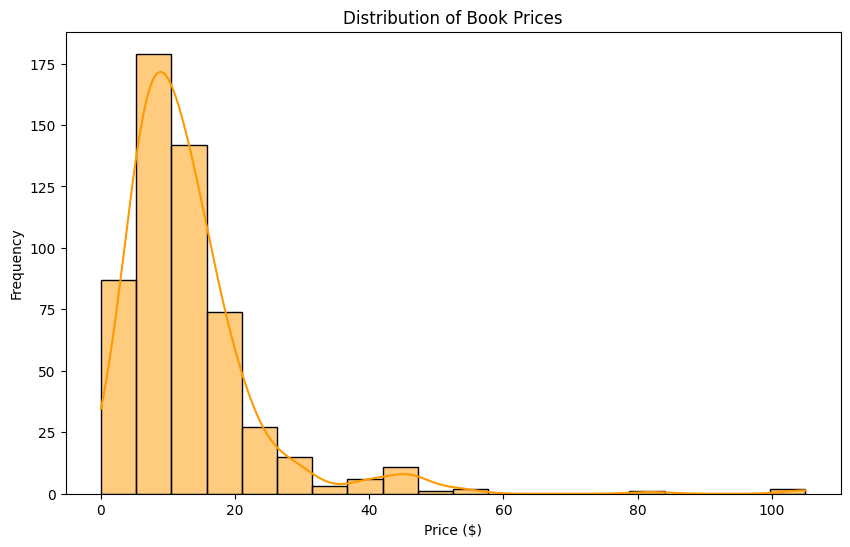

Average Price of a Bestseller: 13.1
Most Expensive Book Price: 105


In [4]:
plt.figure(figsize=(10,6))
sns.histplot(df['Price'], bins=20, kde=True, color='#FF9900') # Amazon Orange
plt.title('Distribution of Book Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

print("Average Price of a Bestseller:", round(df['Price'].mean(), 2))
print("Most Expensive Book Price:", df['Price'].max())

## <a id="5.2"></a> 5.2 User Rating Distribution
How satisfied are customers with these bestselling books? This distribution helps us see if there is enough variation in ratings to perform a correlation analysis.

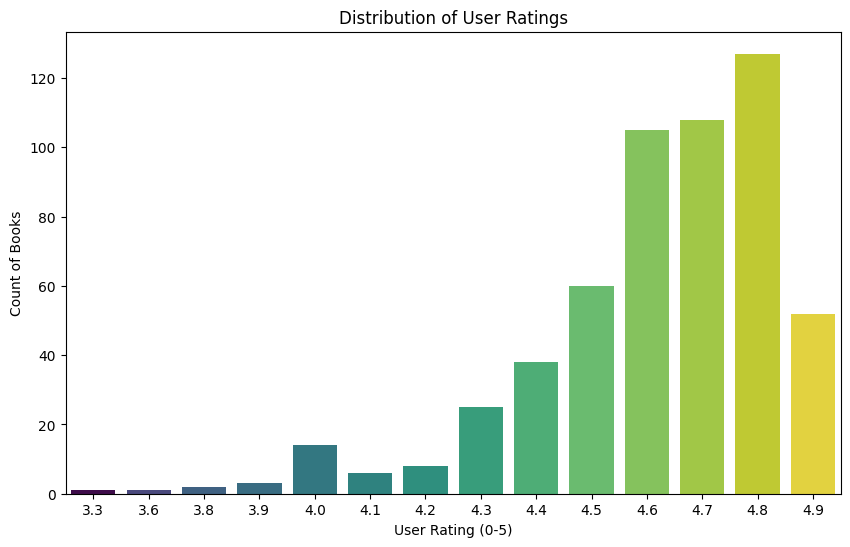

Most Common Rating: 4.8


In [5]:
plt.figure(figsize=(10,6))
sns.countplot(x='User Rating', data=df, hue='User Rating', palette='viridis', legend=False)
plt.title('Distribution of User Ratings')
plt.xlabel('User Rating (0-5)')
plt.ylabel('Count of Books')
plt.show()

print("Most Common Rating:", df['User Rating'].mode()[0])

# <a id="5.3"></a> 5.3 Correlation Analysis (Price vs. Rating)
This is the core of our study. We want to see if expensive books have higher ratings.

Correlation between Price and User Rating: -0.13


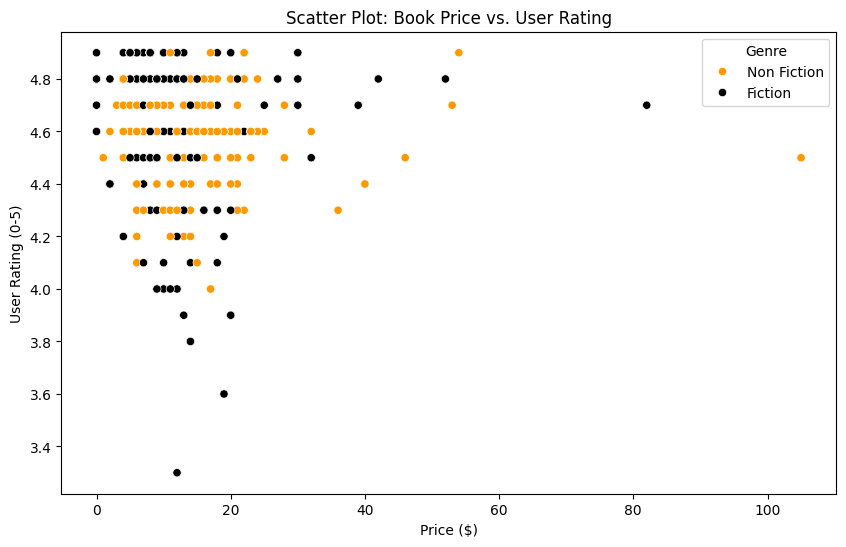

In [6]:
# Statistical Correlation
corr_value = df['Price'].corr(df['User Rating'])
print(f"Correlation between Price and User Rating: {corr_value:.2f}")

# Scatter Plot Visualization
plt.figure(figsize=(10,6))
sns.scatterplot(x='Price', y='User Rating', hue='Genre', data=df, palette=['#FF9900', '#000000'])
plt.title('Scatter Plot: Book Price vs. User Rating')
plt.xlabel('Price ($)')
plt.ylabel('User Rating (0-5)')
plt.show()

# <a id="5.4"></a> 5.4 Fiction vs. Non-Fiction Strategy
How do genres differ in their pricing and popularity?

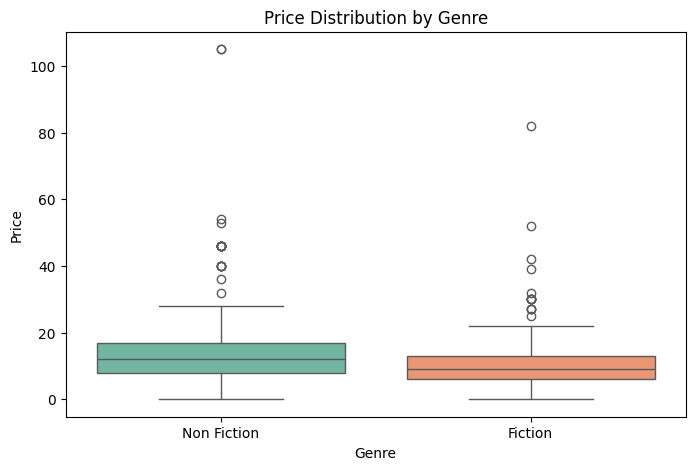

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Genre', y='Price', data=df, palette='Set2', hue='Genre', legend=False)
plt.title('Price Distribution by Genre')
plt.show()

# <a id="6"></a> 6. Key Insights & Strategic Recommendations
1. **Low Correlation:** The correlation value is near zero, suggesting that **Price is NOT a predictor of User Rating** on Amazon.
2. **Affordability Wins:** Most bestsellers are priced under $20, indicating that high-volume sales are driven by competitive pricing.
3. **Genre Trends:** Non-Fiction books tend to have a wider price range compared to Fiction.

# <a id="7"></a> 7. Connection to Tableau Dashboard
This correlation is further explored in our **Tableau Scatter Plot Dashboard**, providing a granular view of every bestselling title.